In [1]:
# Import Library Dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import Library Scikit-learn untuk Preprocessing & Splitting
from sklearn.preprocessing import RobustScaler # Untuk scaling data yang robust terhadap outlier [cite: 70, 338]
from sklearn.model_selection import train_test_split # Untuk membagi data latih dan uji [cite: 70]

In [4]:
# 2. Load Dataset
# Asumsi file 'titanic_data.csv' sudah ditempatkan di direktori '/content/' atau sudah dimuat di sesi (sesuai langkah 74).
df = pd.read_csv('/content/drive/MyDrive/PRAKTIKUM/praktikum13/data/titanic_data.csv')
print("Data Awal (df.head()):")
print(df.head())

Data Awal (df.head()):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0

In [5]:
# Pemeriksaan Missing Values Awal
print("\nMissing Values Awal:")
print(df.isnull().sum())


Missing Values Awal:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
df = pd.read_csv('/content/drive/MyDrive/PRAKTIKUM/praktikum13/data/titanic_data.csv')

In [10]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [11]:
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)

<Axes: >

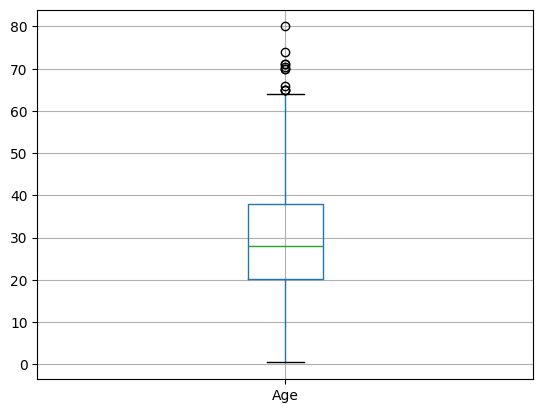

In [12]:
df.boxplot(column='Age')

In [13]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipython-input-1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [14]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipython-input-3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [16]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [18]:
replacements = {
    'Sex': {'male': 0, 'female': 1}, # Male: 0, Female: 1 [cite: 250, 251]
    'Embarked': {'S': 0, 'C': 1, 'Q': 2} # S: 0, C: 1, Q: 2 [cite: 254, 255, 256]
}

# Melakukan penggantian nilai pada DataFrame df secara langsung
df.replace(replacements, inplace=True)

In [19]:
# Melakukan penggantian nilai pada DataFrame df secara langsung
df.replace(replacements, inplace=True)

In [20]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


In [21]:
X = df.drop('Survived', axis=1) # Menghapus kolom 'Survived' dari X [cite: 308, 309]
# y (Label): Kolom 'Survived'
y = df['Survived']

In [22]:
# Inisialisasi RobustScaler. Scaler ini tahan terhadap outlier karena menggunakan Median dan IQR[cite: 337, 338].
scaler = RobustScaler() # [cite: 314, 315]

# Melakukan fit dan transform pada data fitur X
X_scaled = scaler.fit_transform(X)

In [23]:
# Membagi data menjadi 80% data latih (X_train, y_train) dan 20% data uji (X_test, y_test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, # Data fitur yang sudah di-scaling
    y, # Data label
    test_size=0.2, # Proporsi data uji sebesar 20% [cite: 323, 351]
    random_state=42 # Menjaga konsistensi pembagian data [cite: 323, 352, 354]
)

In [24]:
X_train.shape

(712, 8)

In [25]:
X_train.shape[1]

8

In [30]:
# Import library Keras yang diperlukan
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Inisialisasi model sequential
model = Sequential()

# Hidden layer 1
# Dense(32): 32 neuron [cite: 387]
# activation='relu': Menggunakan Rectified Linear Unit sebagai fungsi aktivasi [cite: 36, 387]
# input_shape=(X_train.shape[1],): Menentukan dimensi input, yaitu jumlah fitur (8) [cite: 377, 378, 387]
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Dropout untuk mengurangi overfitting
# model.add(Dropout(0.3)): Menonaktifkan 30% neuron secara acak selama training [cite: 388, 389, 400]
model.add(Dropout(0.3))

# Hidden layer 2
# Dense(16): 16 neuron [cite: 391]
# activation='relu': Menggunakan ReLU [cite: 391]
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3)) # Dropout lagi untuk Hidden Layer 2 [cite: 392]

# Output Layer (Binary Classification)
# Dense(1): 1 neuron, karena ini adalah klasifikasi biner [cite: 394]
# activation='sigmoid': Menggunakan sigmoid untuk menghasilkan probabilitas (output 0 atau 1) [cite: 47, 394, 401]
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Kompilasi model: Menentukan optimizer, loss function, dan metrics.
model.compile(
    optimizer='adam', # Optimizer Adam (Adaptive Moment Estimation) [cite: 437, 438, 439]
    loss='binary_crossentropy', # Fungsi kerugian untuk klasifikasi biner [cite: 440, 442]
    metrics=['accuracy'] # Metrik evaluasi utama [cite: 446, 447, 448]
)

# Menampilkan struktur lengkap model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Import library EarlyStopping dari Keras Callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Inisialisasi callback EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',         # Metrik yang dipantau (Validation Loss) [cite: 467, 468]
    patience=5,                 # Jumlah epoch yang ditunggu jika performa tidak membaik [cite: 470, 471]
    restore_best_weights=True   # Mengembalikan bobot model terbaik yang pernah dicapai [cite: 472, 473]
)

In [33]:
# Melatih model menggunakan data latih (X_train, y_train)
history = model.fit(
    X_train,
    y_train,
    epochs=100,                     # Jumlah maksimum perulangan pelatihan [cite: 539]
    batch_size=16,                  # Jumlah data yang diproses sebelum bobot diperbarui [cite: 539]
    validation_split=0.2,           # 20% dari data latih digunakan sebagai data validasi [cite: 542]
    callbacks=[early_stop],         # Mengaktifkan EarlyStopping [cite: 542]
    verbose=1                       # Menampilkan progres pelatihan [cite: 542]
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5485 - loss: 0.7180 - val_accuracy: 0.6783 - val_loss: 0.6467
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7106 - loss: 0.6148 - val_accuracy: 0.7133 - val_loss: 0.6190
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6967 - loss: 0.6325 - val_accuracy: 0.6923 - val_loss: 0.5964
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: 0.6558 - val_accuracy: 0.7273 - val_loss: 0.5775
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7051 - loss: 0.5883 - val_accuracy: 0.7273 - val_loss: 0.5573
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7464 - loss: 0.5746 - val_accuracy: 0.7203 - val_loss: 0.5434
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7507 - loss: 0.5645 - val_accuracy: 0.7343 - val_loss: 0.5241
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7497 - loss: 0.5543 - val_accuracy: 0.7692 - 

In [36]:
# Evaluasi model pada data uji
loss, accuracy = model.evaluate(X_test, y_test)

# Menampilkan hasil evaluasi
print("Test Loss    :", loss)
print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8285 - loss: 0.4063
Test Loss    : 0.41554489731788635
Test Accuracy: 0.8100558519363403


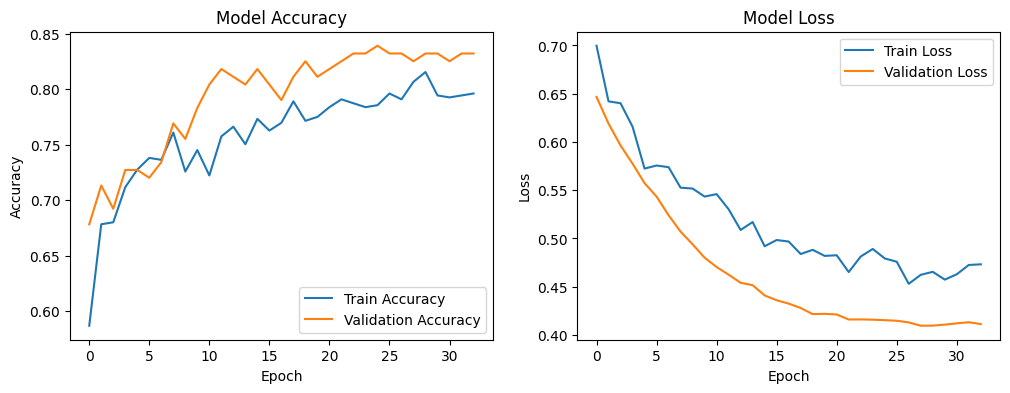

In [37]:
# Import matplotlib jika belum dilakukan di awal
import matplotlib.pyplot as plt

# Mengatur ukuran figure (12x4 inci)
plt.figure(figsize=(12,4))

# --- Plot 1: Accuracy (Train vs Validation) ---
# Membuat subplot pertama (baris 1, kolom 2, plot ke-1)
plt.subplot(1, 2, 1)
# Plot Train Accuracy (diakses dari history.history['accuracy'])
plt.plot(history.history['accuracy'], label='Train Accuracy')
# Plot Validation Accuracy (diakses dari history.history['val_accuracy'])
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- Plot 2: Loss (Train vs Validation) ---
# Membuat subplot kedua (baris 1, kolom 2, plot ke-2)
plt.subplot(1, 2, 2)
# Plot Train Loss (diakses dari history.history['loss'])
plt.plot(history.history['loss'], label='Train Loss')
# Plot Validation Loss (diakses dari history.history['val_loss'])
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Menampilkan semua plot
plt.show()